In [1]:
from IPython.display import display, Image
import matplotlib.pyplot as plt

In [2]:
directions = {'R': (1, 0), 'L': (-1, 0), 'U': (0, 1), 'D': (0, -1)}

In [3]:
def directions_to_steps(dirs: list):
    x, y = 0, 0
    xs = []
    ys = []
    for direction in dirs:
        dx, dy = directions[direction]
        x, y = dx + x, dy + y
        xs.append(x)
        ys.append(y)
    
    return xs, ys

In [4]:
raw =   'PPHHHPPPPHHHHHPHPPPP'
dirs = 'RDDRUURRDLDDLLDRRRUU'
x, y = directions_to_steps(dirs)
print(x)
print(y)

[1, 1, 1, 2, 2, 2, 3, 4, 4, 3, 3, 3, 2, 1, 1, 2, 3, 4, 4, 4]
[0, -1, -2, -2, -1, 0, 0, 0, -1, -1, -2, -3, -3, -3, -4, -4, -4, -4, -3, -2]


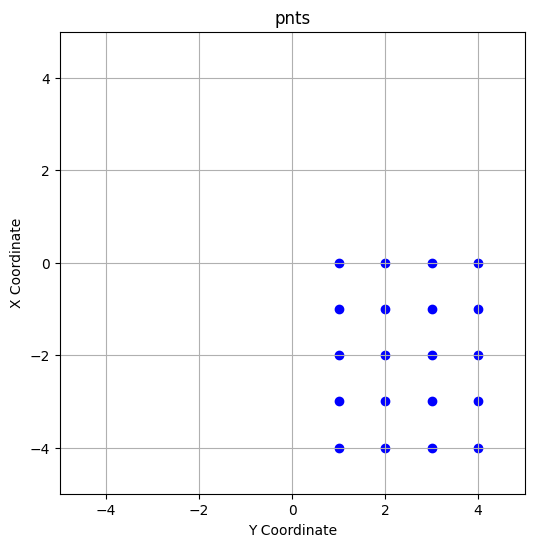

In [5]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, color='blue') 

plt.xlim(-5, 5)
plt.ylim(-5, 5)


plt.grid(True)

plt.xlabel('Y Coordinate')
plt.ylabel('X Coordinate')

plt.title('pnts')
plt.gca()

plt.show()

In [6]:
def create_visual(raw_string, directions):
    visual = []
    for type, dir in zip(raw_string, directions):
        visual.append(dir+type)
    return visual

visual = create_visual(raw, dirs)
visual

['RP',
 'DP',
 'DH',
 'RH',
 'UH',
 'UP',
 'RP',
 'RP',
 'DP',
 'LH',
 'DH',
 'DH',
 'LH',
 'LH',
 'DP',
 'RH',
 'RP',
 'RP',
 'UP',
 'UP']

[(30, 31), (31, 31), (32, 31), (32, 32), (31, 32), (30, 32), (30, 33), (30, 34), (31, 34), (31, 33), (32, 33), (33, 33), (33, 32), (33, 31), (34, 31), (34, 32), (34, 33), (34, 34), (33, 34), (32, 34)]


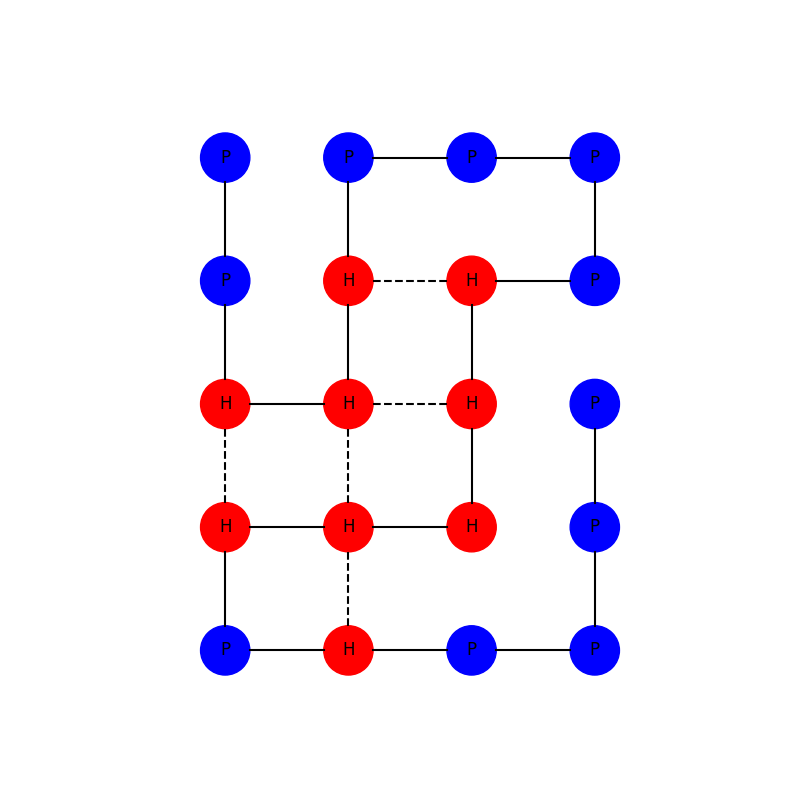

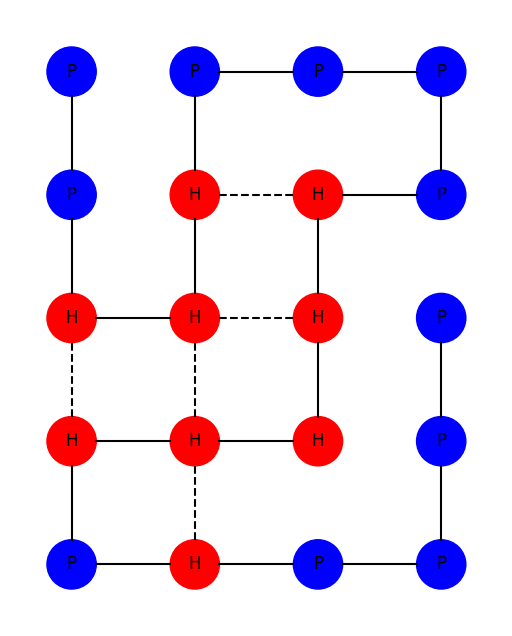

In [7]:
import matri

def show(visual_code: list):
    img = matri.create_lattice_diagram(visual_code)
    display(Image(img))

def multiple_show(visual_codes: list):
    imgs = []
    for visual_code in visual_codes:
        img = matri.create_lattice_diagram(visual_code)
        imgs.append(Image(img))
    display(tuple(imgs))
    

show(visual)

<h1>Generate first chromosome<h1>

RDLLDRDLDRDLLLDRDDLL
[(30, 31), (31, 31), (31, 30), (31, 29), (32, 29), (32, 30), (33, 30), (33, 29), (34, 29), (34, 30), (35, 30), (35, 29), (35, 28), (35, 27), (36, 27), (36, 28), (37, 28), (38, 28), (38, 27), (38, 26)]


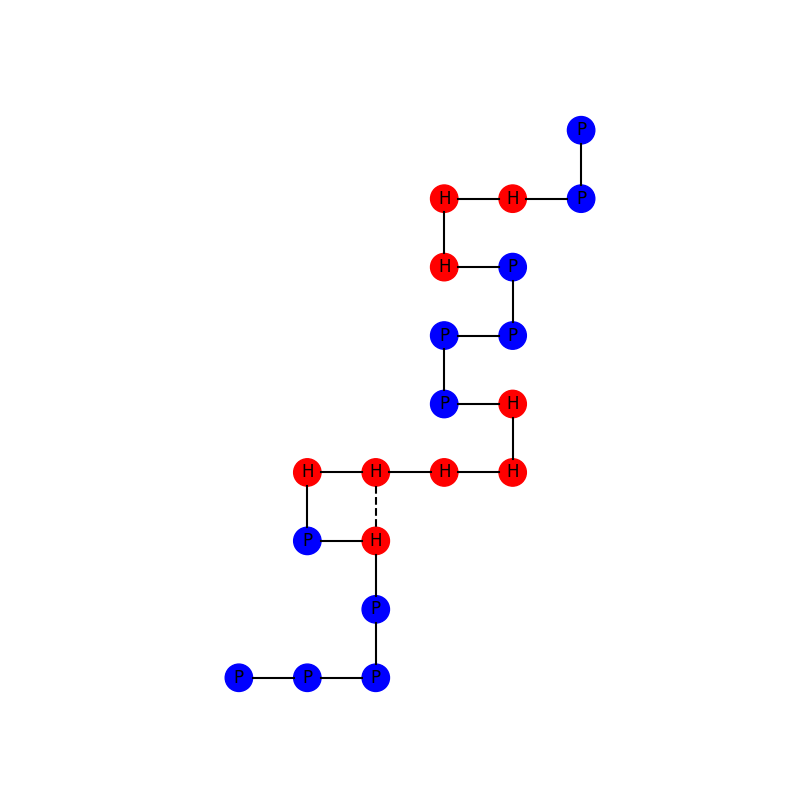

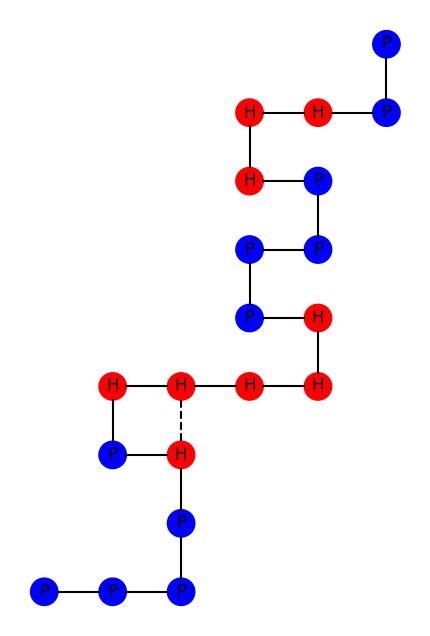

In [8]:
raw = "PPHHHPPPPHHHHHPHPPPP"
from chromosome import Chromosome

valid_chr = None

while True:
    chromosome = Chromosome()
    valid = chromosome.generate(len(raw))
    if valid:
        valid_chr = chromosome
        break

print(valid_chr.ruld)

visual = create_visual(raw, valid_chr.ruld)
show(visual)


In [9]:
from utils import is_valid

print(valid_chr.ruld)
print(valid_chr.xs)
print(len(valid_chr.xs))
print(valid_chr.ys)
print(len(valid_chr.ys))

print(len(valid_chr.ruld), len('PPHHHPPPPHHHHHPHPPPP'))

is_valid(valid_chr, 'PPHHHPPPPHHHHHPHPPPP')

RDLLDRDLDRDLLLDRDDLL
[0, 1, 1, 0, -1, -1, 0, 0, -1, -1, 0, 0, -1, -2, -3, -3, -2, -2, -2, -3, -4]
21
[0, 0, -1, -1, -1, -2, -2, -3, -3, -4, -4, -5, -5, -5, -5, -6, -6, -7, -8, -8, -8]
21
20 20


True

<h1>Fitness function</h1>


In [10]:
def adjacent(a: tuple, b: tuple) -> bool:
    x1, y1 = a
    x2, y2 = b
    return (x1 == x2 and abs(y1 - y2) == 1) or (y1 == y2 and abs(x1 - x2) == 1)

def fitness(chromosome : Chromosome, raw: str) -> int :
    fitness = 0
    for i in range(len(raw)):
        if raw[i] == 'H':
            cx = chromosome.xs[i]
            cy = chromosome.ys[i]
            for j in range(len(raw)):
                nx = chromosome.xs[j]
                ny = chromosome.ys[j]
                if raw[j] == 'H' and adjacent((cx, cy), (nx, ny)) and abs(i-j) > 1:
                    fitness += 1
    return -fitness//2
                    

In [11]:
raw =  'PPHHHPPPPHHHHHPHPPPP'
dirs = 'RURDRUULUUULLLURRUUR'
x, y = directions_to_steps(dirs)

chr = Chromosome()
chr.cp(dirs, x, y)

print(fitness(chr, raw))


-1


<h1>Change direction<h1>

before change:  RRDDLULDLLUULULDLUUR
after  change:  RRDDLULDLLULLULDLUUR
[(30, 31), (30, 32), (31, 32), (32, 32), (32, 31), (31, 31), (31, 30), (32, 30), (32, 29), (32, 28), (31, 28), (30, 28), (30, 27), (29, 27), (29, 26), (30, 26), (30, 25), (29, 25), (28, 25), (28, 26)]


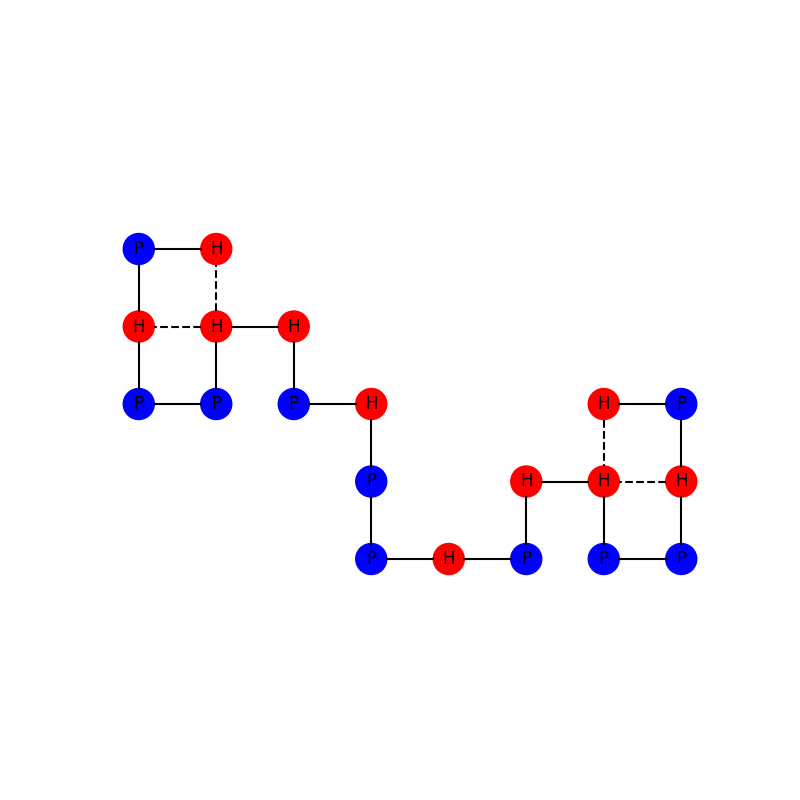

[(30, 31), (30, 32), (31, 32), (32, 32), (32, 31), (31, 31), (31, 30), (32, 30), (32, 29), (32, 28), (31, 28), (31, 27), (31, 26), (30, 26), (30, 25), (31, 25), (31, 24), (30, 24), (29, 24), (29, 25)]


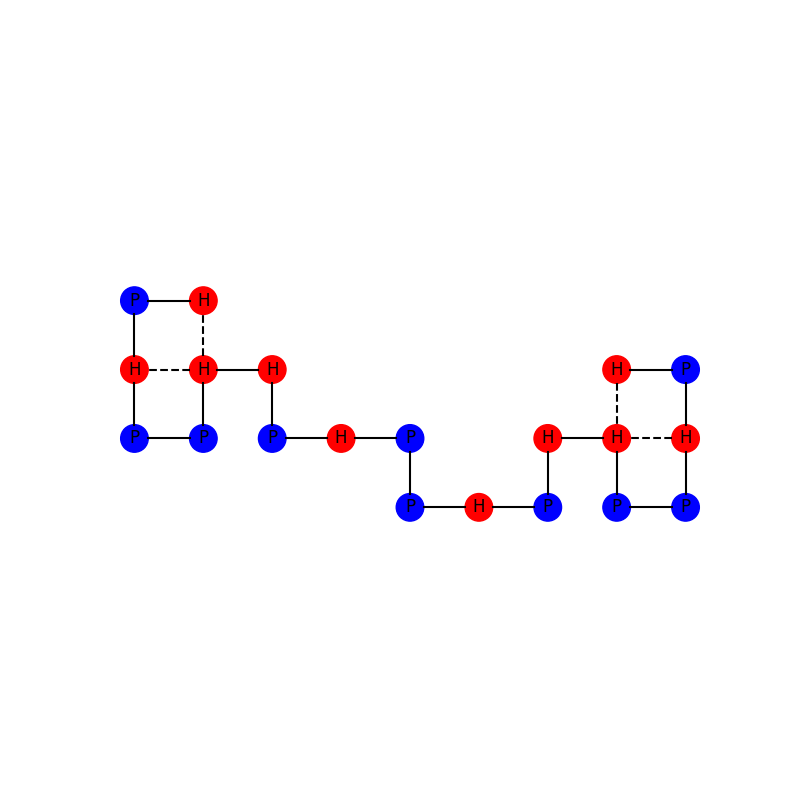

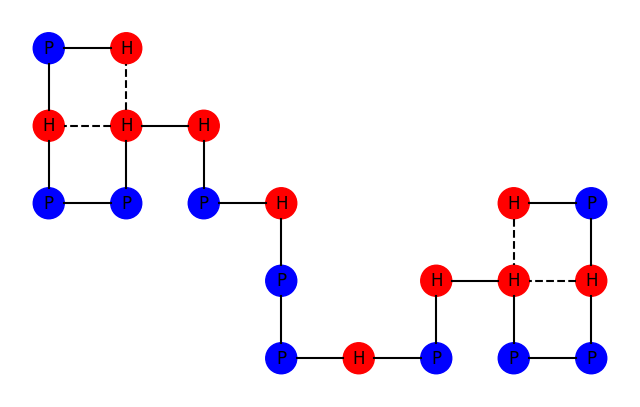

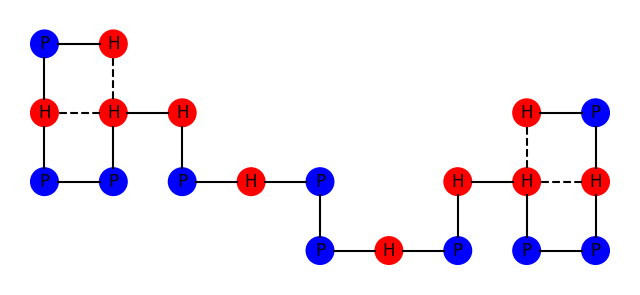

In [12]:
raw =  'HPHPPHHPHPPHPHHPPHPH'
dirs = 'RRDDLULDLLUULULDLUUR'

x, y = directions_to_steps(dirs)

chr = Chromosome()
chr.cp(dirs, x, y)


chr.change(11)

print("before change: ", dirs)
print("after  change: ", chr.ruld)

initial_visual = create_visual(raw, dirs)
after_visual = create_visual(raw, chr.ruld)
show(initial_visual) 
show(after_visual)


<h1> Square inside </h1>

[(29, 30), (28, 30), (27, 30), (27, 29), (27, 28), (28, 28)]


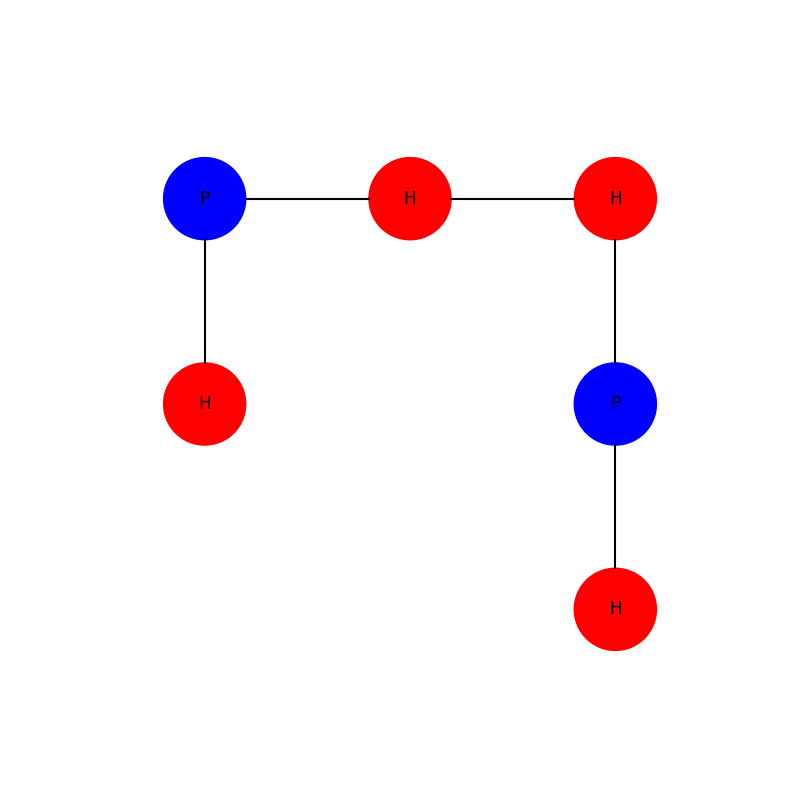

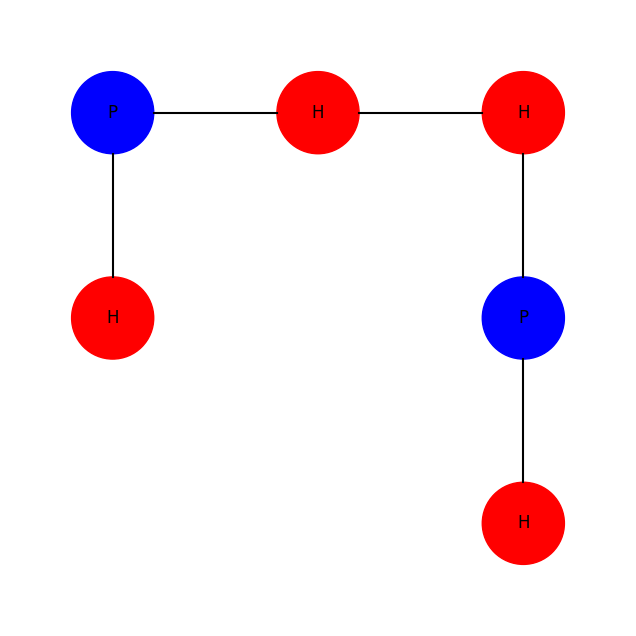

In [13]:
raw =  'HPHHPH'
dirs = 'UUULLD'

x, y = directions_to_steps(dirs)

chr = Chromosome()
chr.cp(dirs, x, y)
initial_visual = create_visual(raw, dirs)
show(initial_visual)

[(29, 30), (28, 30), (28, 29), (27, 29), (27, 28), (28, 28)]


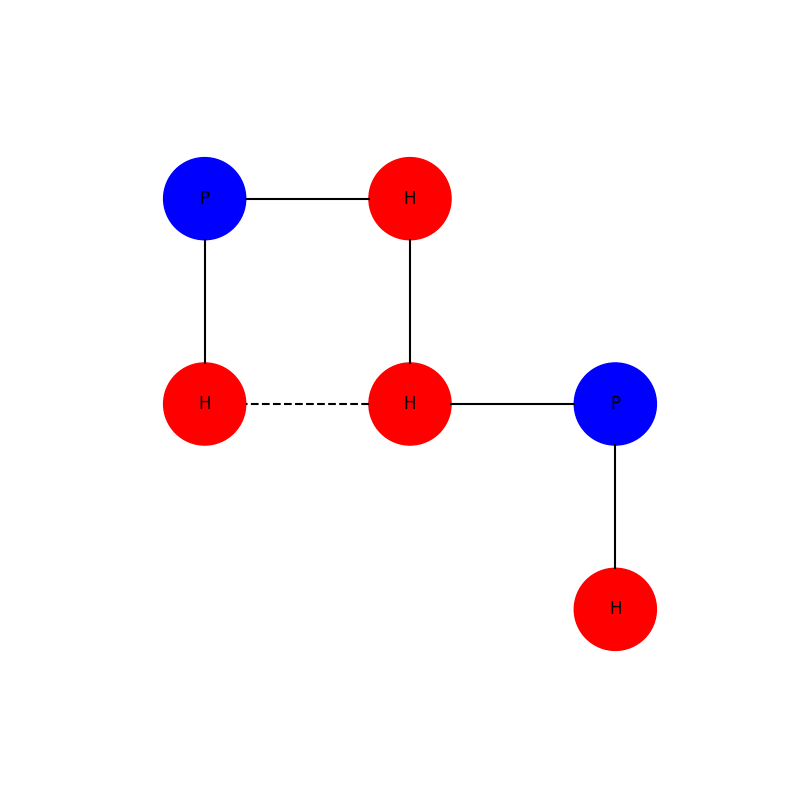

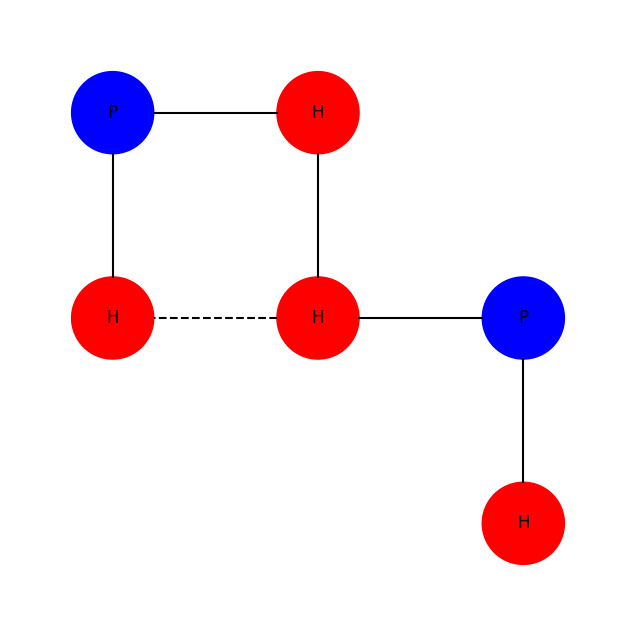

In [14]:
chr.diagonal()
after_visual = create_visual(raw, chr.ruld)
show(after_visual)

[(30, 31), (31, 31), (31, 30), (31, 29), (32, 29), (32, 30), (33, 30), (33, 29), (34, 29), (34, 30), (35, 30), (35, 29), (35, 28), (35, 27), (36, 27), (36, 28), (37, 28), (38, 28), (38, 27), (38, 26)]

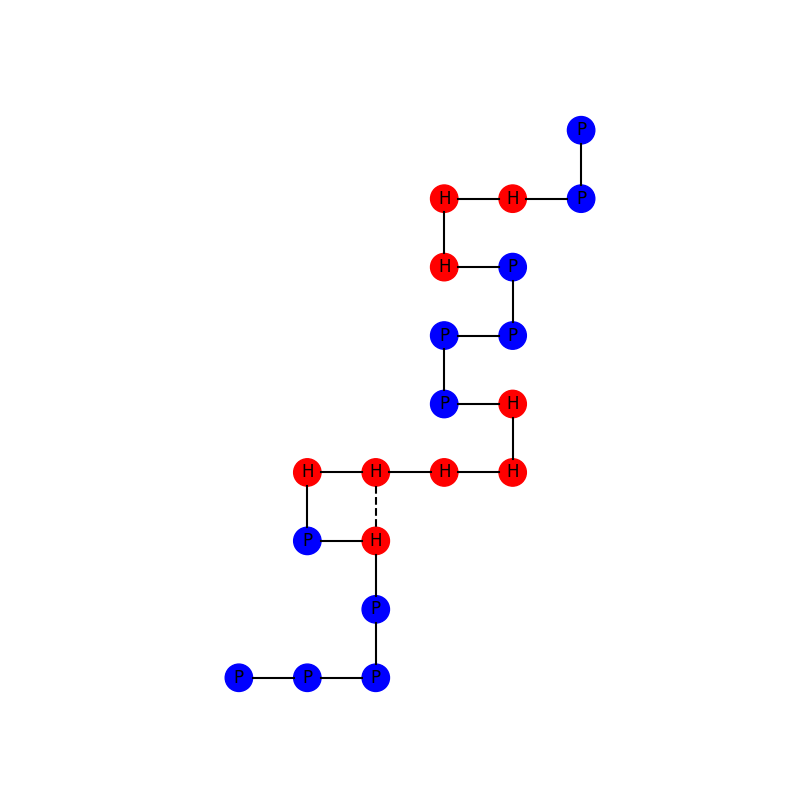

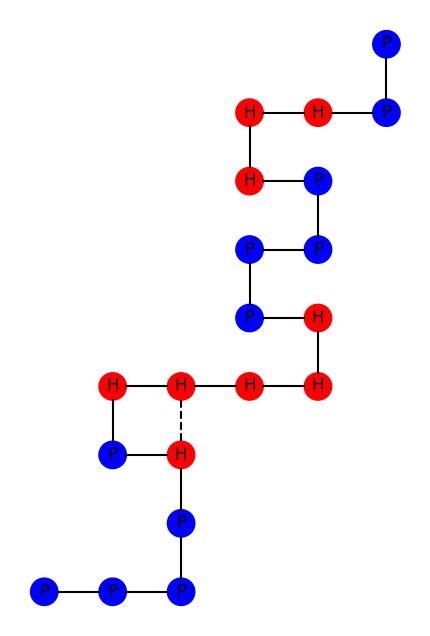

In [15]:
vissual = ['RH', 'DP', 'LP', 'DH', 'LP', 'UP', 'UP', 'LH', 'LP', 'UP', 'LH', 'UP', 'UP', 'RP', 'DP', 'RH', 'DH', 'RH', 'UH', 'UH', 'UP', 'UP']
show(visual)